In [1]:
### Import libraries and set plot style

import numpy as np
from scipy.optimize import curve_fit
from os import listdir
from cycler import cycler
import matplotlib.pyplot as plt
import matplotlib.transforms as trans
colors = ['#202020', '#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#bcbd22', '#e377c2', '#17becf', '#1f5a0a', '#8c564b', '#7f7f7f']
         ## black    red        blue       green      orange     violet     yellow     pink       lightblue  darkgreen  dirty-red  grey
plt.rcParams.update({'font.size': 15.5,
                     'axes.titlepad': 25,
                     'axes.labelpad': 20,
                     'axes.labelsize': 20,
                     'xtick.labelsize' : 15.5,
                     'ytick.labelsize' : 15.5,
                     'axes.prop_cycle': cycler('color', colors),
                     #'axes.grid': True,
                     'axes.linewidth': 0.5,
                     'lines.linewidth': 1.5,
                     'lines.markersize': 5,
                     'scatter.marker': 'o',
                     #'errorbar.capsize': 2,
                     'figure.dpi': 100.0,
                     'figure.figsize': [8, 5],
                     'xtick.top' : True,
                     'ytick.right' : True,
                     'xtick.direction' : 'out',
                     'ytick.direction' : 'out',
                     'xtick.major.size': 8,
                     'xtick.minor.size': 4,
                     'ytick.major.size': 8,
                     'ytick.minor.size': 4,
                     'xtick.major.width': 0.5,
                     'xtick.minor.width': 0.5,
                     'ytick.major.width': 0.5,
                     'ytick.minor.width': 0.5})

In [2]:
def background(t_i, t_f) :
    runs = 2
    Nruns = [0]
    gaschange = [4213/3600, 8802/3600, t_f]
    gaslabels = ["N$_2$", "CO$_2$"]

    g = plt.gca()
    t = trans.blended_transform_factory(g.transData, g.transAxes)
    colors = ['pink', 'lightgreen']
    h = 0.05
    s = Nruns[0]
    
    plt.text(gaschange[0] - 0.07, h, "air", ha='center', transform=t)
    for i in range (0, runs) :
        plt.axvspan(gaschange[i], gaschange[i+1], color=colors[s])
        plt.text((gaschange[i] + gaschange[i+1]) / 2, h, gaslabels[s], ha='center', transform=t)
        s = not s
    

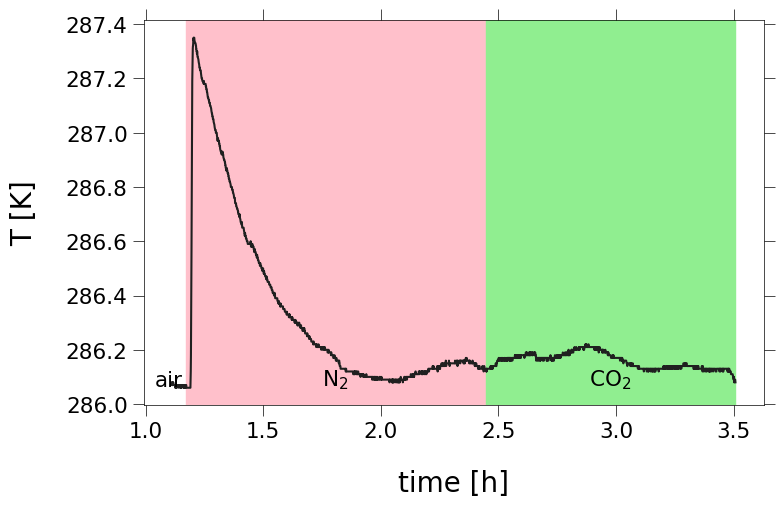

In [3]:
file = "11-22_EMPTY-SILICA_N2_CO2_3.TXT"
data = np.genfromtxt(file, delimiter='\t', skip_header=4)

mask = data[:,-1] > 4e3
data = data[mask]

T_ = data[:,-2]
t_ = data[:,-1]/3600

background(t_[0], t_[-1])

plt.plot(t_, T_)
plt.xlabel("time [h]")
plt.ylabel("T [K]")
plt.show()

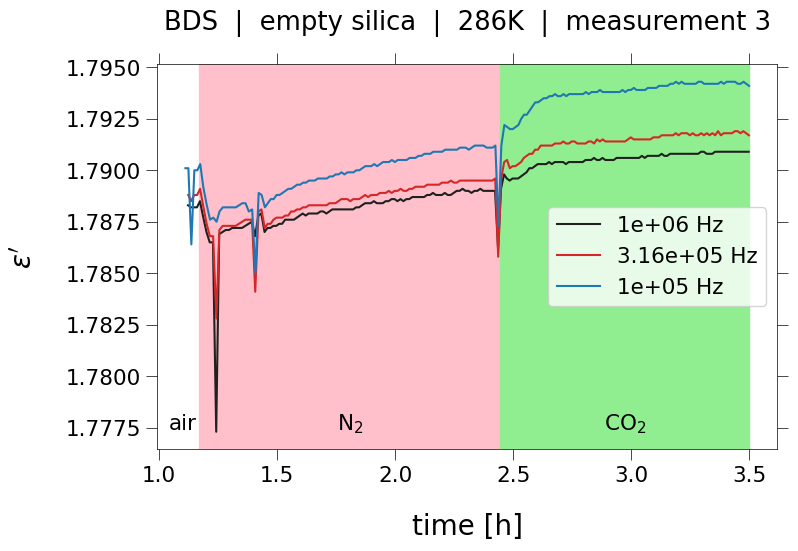

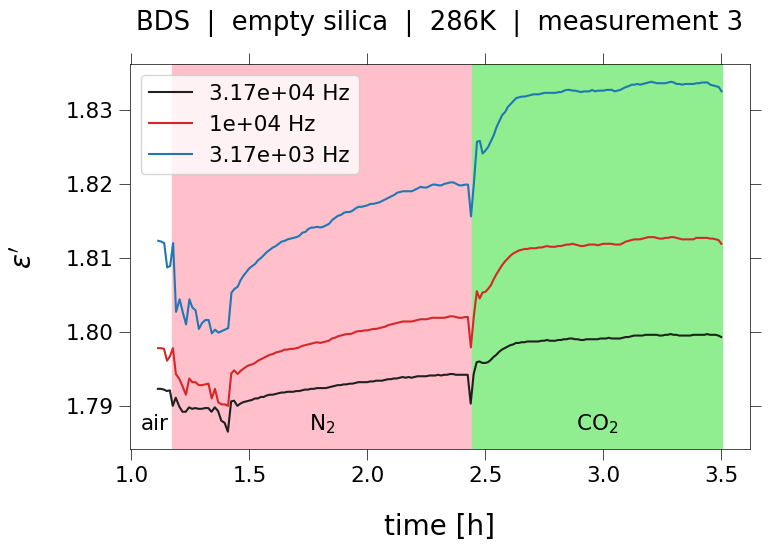

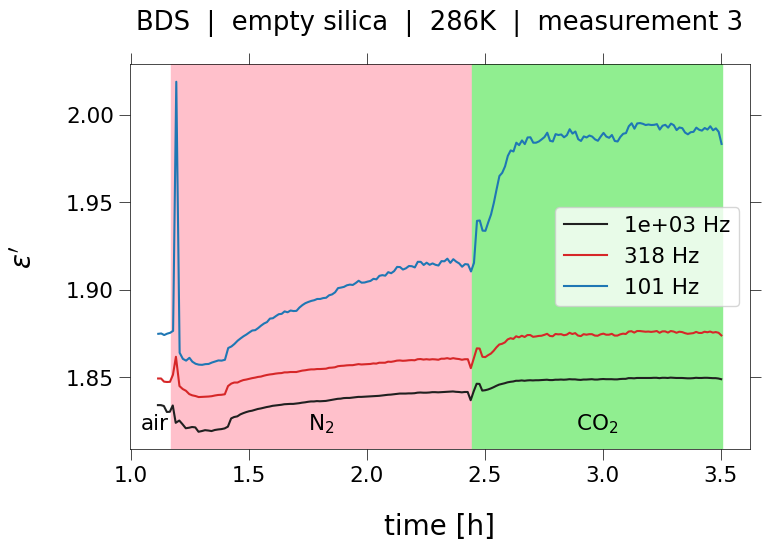

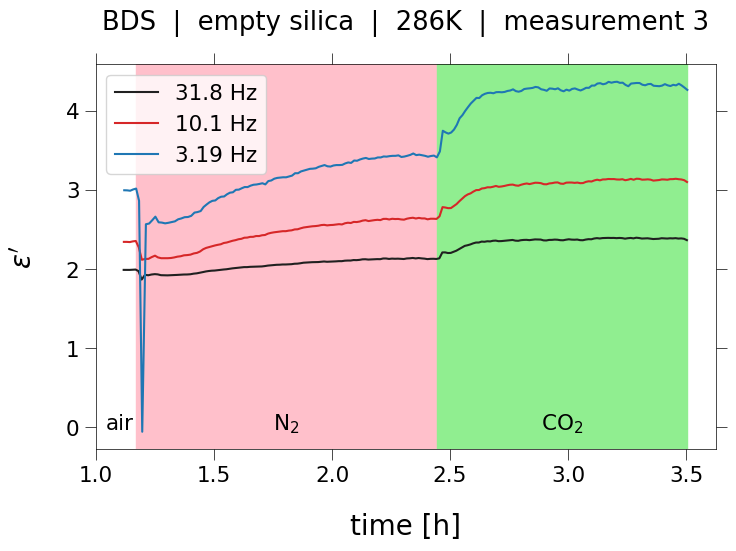

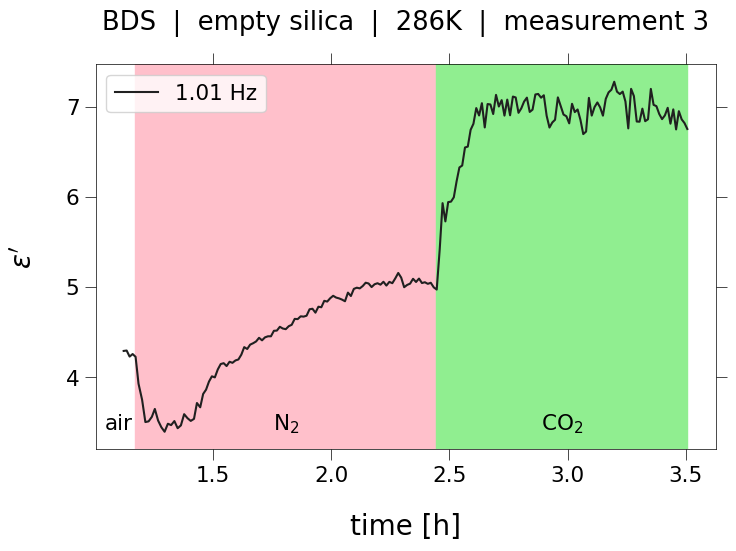

In [ ]:
e_lab = ["$\epsilon'$", "$\epsilon''$"]

k=0
while data[k][0] != 1e6 :
    k+=1

e_inds = [2] #[2,3]
for e_ind in e_inds : 
    for i in np.arange(0,13) :
        F = data[i+k][0]
        F_str = "{:.3g}".format(F)
        
        lines = data[:,0] == F
        data_i = data[lines]
        e = data_i[:,e_ind]
        t = data_i[:,-1]/3600.0

        plt.plot(t, e, label=F_str+" Hz")

        if i%3 == 2 or i==12 :
            background(t[0], t[-1])
            plt.title("BDS  |  empty silica  |  286K  |  measurement 3")
            plt.xlabel("time [h]")
            plt.ylabel(e_lab[e_ind-2])
            plt.legend()
            #plt.savefig(f"results3/{i}.pdf", bbox_inches='tight')
            plt.show()